In [1]:
from pathlib import Path

In [2]:
OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

In [3]:
import pandas as pd

df = pd.read_csv(OUTPUT / "dataset_winsize12h.csv")
df

,fold_id,num_events,num_unique_ptids,num_69kv_lines,num_115kv_lines,num_132kv_lines,num_220kv_lines,num_345kv_lines,num_500kv_lines,num_735kv_lines,...,num_events_last_60_min,num_events_last_120_min,node_degree_mean,node_degree_std,node_degree_min,node_degree_max,label_is_auto,label_time_to_event_seconds,label_from_zone,label_to_zone
0,0,1,1,0,1,0,0,0,0,0,...,0,1,3.000000,0.000000,3,3,True,3600.0,12,12
1,2,2,2,0,2,0,0,0,0,0,...,1,2,2.500000,0.500000,2,3,True,0.0,12,12
2,2,1,1,0,0,1,0,0,0,0,...,1,1,5.500000,0.500000,5,6,True,1800.0,17,17
3,2,8,8,0,0,7,1,0,0,0,...,0,0,4.937500,3.230107,2,11,True,9600.0,22,22
4,2,2,2,0,0,2,0,0,0,0,...,0,0,3.000000,1.732051,2,6,True,18000.0,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8003,2,19,19,0,8,2,8,1,0,0,...,0,1,7.078947,5.569568,1,22,True,5700.0,12,12
8004,2,3,3,0,1,0,1,1,0,0,...,1,1,4.833333,3.933475,1,13,True,900.0,2,2
8005,0,4,4,0,1,1,1,1,0,0,...,2,2,6.625000,4.608077,1,13,True,0.0,2,2
8006,2,6,6,0,1,3,1,1,0,0,...,4,4,6.833333,4.669642,1,13,True,0.0,2,2


In [4]:
x = df["label_time_to_event_seconds"].to_numpy()

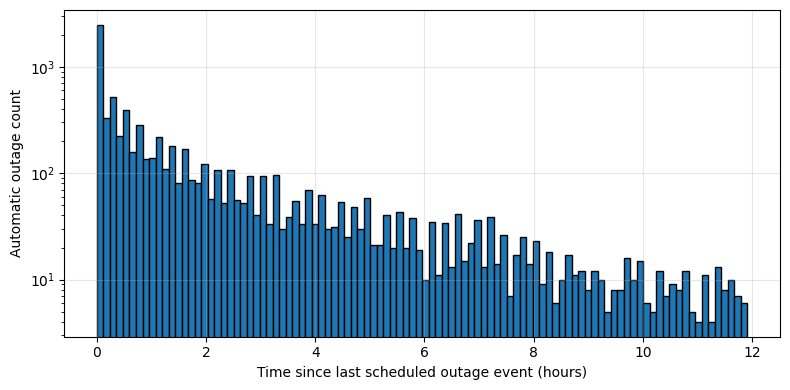

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([i / 3600 for i in x], bins=100, edgecolor="black")
ax.set_xlabel("Time since last scheduled outage event (hours)")
ax.set_ylabel("Automatic outage count")
ax.set_yscale("log")
# ax.set_xscale("log")

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT / "auto_outage_time_since_schedule_histogram.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()